# Calculadora de Ancestralidade Genômica com o 1000 Genomes

Compara o genótipo de um indivíduo, obtido por microarray Illumina, com os
3.202 indivíduos de referência do 1000 Genomes Project (26 populações, 5
superpopulações), produzindo uma análise de afinidade genética populacional:
harmonização de variantes, frequências alélicas, PCA, distância a
centroides, classificação supervisionada, modelo de mistura por
frequências, validação interna e interpretação dos resultados.

Portátil (roda local ou no Google Colab). Passos computacionalmente pesados
(exportação PLINK2, PCA, classificador) salvam o resultado em
`outputs/intermediate/` e `outputs/figures/` na primeira execução; em
reexecuções, recarregam do cache em vez de recalcular.

## 1. Visão geral do projeto

O sistema recebe o genótipo de um indivíduo genotipado por microarray da
Illumina, compara com os indivíduos de referência do 1000 Genomes Project
e produz uma análise de proximidade genética com as 26 populações do
projeto — cobrindo representação de variantes, harmonização REF/ALT,
controle de qualidade, LD pruning, PCA, distâncias/classificação, modelo
de mistura, validação e interpretação crítica dos limites do método.

> **Nada a executar aqui** — é a introdução do enunciado; o restante do
> notebook implementa exatamente essa visão geral, capítulo por capítulo.

## 2. Problema

O arquivo do indivíduo (`genotipo_microarray.csv`) tem colunas `Index`,
`Name`, `Address`, `Chr`, `Position` e `35.Genotipo`. O campo `Name` é o
identificador do marcador Illumina, **não** é rsID — a integração com o
1000 Genomes não pode usar `Name` como se fosse um rsID universal; ela foi
feita pelo professor via coordenadas (`Chr`/`Position`) e já está resolvida
no `harmonization_map.csv` que usamos a partir da seção 9.

In [1]:
from pathlib import Path
import os
import pandas as pd

# Detecta o ambiente (local vs. Colab) uma única vez — todo o resto do
# notebook reaproveita ROOT e _EM_COLAB definidos aqui.
try:
    import google.colab  # só existe dentro do Colab
    _EM_COLAB = True
except ImportError:
    _EM_COLAB = False

if _EM_COLAB:
    # No Colab não há um clone local do projeto ainda: baixamos o repositório
    # do GitHub pra ter acesso a src/harmonization.py e manter a mesma
    # estrutura outputs/intermediate usada localmente (cache dos resultados).
    import subprocess
    _repo_dir = Path("/content/faculdade-atividade-1")
    if not _repo_dir.exists():
        subprocess.run(
            ["git", "clone", "https://github.com/wrnsthetic/faculdade-atividade-1.git", str(_repo_dir)],
            check=True,
        )
    ROOT = _repo_dir
else:
    # Local: raiz do projeto é a pasta-mãe de notebooks/ (ou a própria pasta
    # atual, se o notebook for executado a partir da raiz)
    ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# preview rápido do arquivo bruto do indivíduo, só pra ilustrar o formato da seção 2
_preview_path = (Path(os.environ.get("ANCESTRY_DATA_DIR", ROOT / "Data")) / "individuo" / "genotipo_microarray.csv")
if _preview_path.exists():
    display(pd.read_csv(_preview_path, nrows=5))
else:
    # esperado no Colab antes da seção 7 montar o Google Drive
    print(f"Pré-visualização indisponível ainda ({_preview_path} não existe) — "
          "os dados são montados via Google Drive na seção 7; reexecute esta "
          "célula depois se quiser ver o preview.")

,Index,Name,Address,Chr,Position,35.Genotipo
0,1,1:103380393,9663149,1,102914837,GG
1,2,1:109439680,26641362,1,108897058,AA
2,3,1:110198788,5682188,1,109656166,TT
3,4,1:110201112,21701591,1,109658490,CC
4,5,1:110201667,79803181,1,109659045,CC


## 3. As 26 populações do 1000 Genomes

AFR (African): ACB, ASW, ESN, GWD, LWK, MSL, YRI — AMR (Admixed American):
CLM, MXL, PEL, PUR — EAS (East Asian): CDX, CHB, CHS, JPT, KHV — EUR
(European): CEU, FIN, GBR, IBS, TSI — SAS (South Asian): BEB, GIH, ITU,
PJL, STU. O Phase 3 clássico do 1000 Genomes tem 2.504 indivíduos nessas
26 populações; a referência preparada para esta disciplina usa 3.202
(seção 5).

In [2]:
# Confere que metadata_populations.csv reflete exatamente essa tabela de referência
METADATA_PATH = (Path(os.environ.get("ANCESTRY_DATA_DIR", ROOT / "Data")) / "processed" / "metadata_populations.csv")
if METADATA_PATH.exists():
    _metadata_preview = pd.read_csv(METADATA_PATH)
    print(f"Indivíduos na referência: {len(_metadata_preview)} (esperado: 2.504 no Phase 3 clássico; "
          f"aqui a referência preparada tem {len(_metadata_preview)}, ver seção 5)")
    print(f"Populações: {_metadata_preview['Population'].nunique()} | Superpopulações: "
          f"{sorted(_metadata_preview['SuperPop'].unique())}")
    display(_metadata_preview.groupby("SuperPop")["Population"].unique())
else:
    # esperado no Colab antes da seção 7 montar o Google Drive
    print(f"Metadados indisponíveis ainda ({METADATA_PATH} não existe) — "
          "os dados são montados via Google Drive na seção 7; reexecute esta "
          "célula depois se quiser ver a conferência.")

Indivíduos na referência: 3202 (esperado: 2.504 no Phase 3 clássico; aqui a referência preparada tem 3202, ver seção 5)
Populações: 26 | Superpopulações: ['AFR', 'AMR', 'EAS', 'EUR', 'SAS']


SuperPop
AFR    [ACB, GWD, ESN, MSL, YRI, LWK, ASW]
AMR                   [PUR, CLM, PEL, MXL]
EAS              [CHS, CDX, KHV, CHB, JPT]
EUR              [GBR, FIN, IBS, CEU, TSI]
SAS              [PJL, BEB, STU, ITU, GIH]
Name: Population, dtype: object

## 4. Interpretação científica

Uma população do 1000 Genomes **não** representa necessariamente uma
ancestralidade ancestral "pura". Populações como PUR, CLM, MXL e PEL são
populações contemporâneas admixed, com histórias demográficas próprias.
Um resultado do tipo "IBS 35%, TSI 24%, PUR 15%, YRI 8%..." não deve ser
lido como percentual literal de nacionalidade — é afinidade genética
relativa ao painel de referência disponível.

> **Nada a executar aqui** — esse aviso é conceitual; ele reaparece em
> código/markdown sempre que produzimos um resultado numérico (seções 25 e
> 29), pra não deixar essa ressalva só no início e esquecida no final.

## 5. Preparação prévia da referência

A referência (1000 Genomes GRCh38 + manifesto Illumina GSA v3) já foi
filtrada, harmonizada (REF/ALT, correção de strand) e reduzida pelo
professor antes desta disciplina — resultando em 573.028 SNPs
harmonizados com correspondência única aos marcadores do microarray. Essa
etapa **não** faz parte do trabalho do aluno.

> **Nada a executar aqui** — os artefatos dessa preparação (pasta
> `processed/`) são o ponto de partida do notebook a partir da seção 7.

## 6. Organização dos dados no Google Drive

Estrutura oficial do Drive (`Projeto_Ancestralidade/`): `individuo/`,
`manifesto/`, `referencia/` (arquivos originais, só rastreabilidade) e
`processed/` (o que de fato é usado). Localmente, `Data/` na raiz deste
projeto espelha exatamente essa estrutura.

> **Nada a executar aqui** — a célula de configuração da seção 7 é quem
> efetivamente aponta para essa estrutura, local ou via Drive montado.

## 7. Conectando o Colab ao Google Drive

Célula portátil: detecta se está rodando localmente (pasta `Data/` na raiz
do projeto, ou variável de ambiente `ANCESTRY_DATA_DIR`) ou no Colab (monta
o Google Drive automaticamente). O resto do notebook usa só as variáveis
`BASE`, `INDIVIDUO`, `PROCESSED` etc. definidas aqui — nenhuma célula depois
desta tem caminho fixo.

In [3]:
# Caminho-base dos dados: local (pasta Data/ na raiz do projeto) ou Colab
# (Google Drive montado). _EM_COLAB e ROOT já foram definidos na seção 2.
if _EM_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE = Path(os.environ.get("ANCESTRY_DATA_DIR", "/content/drive/MyDrive/Projeto_Ancestralidade"))
    AMBIENTE = "Colab"
else:
    BASE = Path(os.environ.get("ANCESTRY_DATA_DIR", ROOT / "Data"))
    AMBIENTE = "local"

# subpastas espelhando a estrutura do Drive (seção 6)
INDIVIDUO = BASE / "individuo"
PROCESSED = BASE / "processed"
GENOTIPO = INDIVIDUO / "genotipo_microarray.csv"
PGEN = PROCESSED / "1000G_GSA_SNP.pgen"
PVAR = PROCESSED / "1000G_GSA_SNP.pvar.zst"
PSAM = PROCESSED / "1000G_GSA_SNP.psam"
MAPA = PROCESSED / "harmonization_map.csv"
METADATA = PROCESSED / "metadata_populations.csv"

# onde este notebook guarda resultados intermediários (cache) e figuras
INTERMEDIATE = ROOT / "outputs" / "intermediate"
FIGURES = ROOT / "outputs" / "figures"
INTERMEDIATE.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

import sys
sys.path.insert(0, str(ROOT))  # pra importar src/harmonization.py

print(f"Ambiente: {AMBIENTE}")
print(f"Base de dados: {BASE}")

# checagem de existência dos arquivos essenciais antes de seguir
_arquivos_necessarios = [GENOTIPO, PGEN, PVAR, PSAM, MAPA, METADATA]
_faltantes = [a for a in _arquivos_necessarios if not a.exists()]
if _faltantes:
    raise FileNotFoundError("Arquivos ausentes:\n" + "\n".join(map(str, _faltantes)))
for _arquivo in _arquivos_necessarios:
    print(f"OK  {_arquivo.relative_to(BASE)} ({_arquivo.stat().st_size / 1e6:.1f} MB)")

Ambiente: local
Base de dados: C:\Code\Faculdade\atividade-1\Data
OK  individuo\genotipo_microarray.csv (28.9 MB)
OK  processed\1000G_GSA_SNP.pgen (269.4 MB)
OK  processed\1000G_GSA_SNP.pvar.zst (113.5 MB)
OK  processed\1000G_GSA_SNP.psam (0.1 MB)
OK  processed\harmonization_map.csv (32.3 MB)
OK  processed\metadata_populations.csv (0.1 MB)


In [4]:
# PLINK 2: usado nas seções 8 (exportar a matriz da referência) e 13 (LD pruning).
# Local: espera o binário Windows em tools/plink2/plink2.exe (baixado à parte,
# não versionado). Colab: baixa o build Linux automaticamente na primeira vez.
import zipfile
import urllib.request

def get_plink2() -> Path:
    if AMBIENTE == "local":
        local_exe = ROOT / "tools" / "plink2" / "plink2.exe"
        if local_exe.exists():
            return local_exe
        raise FileNotFoundError(
            f"plink2.exe não encontrado em {local_exe}. Baixe o build Windows em "
            "https://www.cog-genomics.org/plink/2.0/ e extraia em tools/plink2/."
        )
    plink_dir = ROOT / "tools" / "plink2"
    plink_dir.mkdir(parents=True, exist_ok=True)
    linux_exe = plink_dir / "plink2"
    if not linux_exe.exists():
        url = "https://s3.amazonaws.com/plink2-assets/alpha7/plink2_linux_avx2_20260818.zip"
        zip_path = plink_dir / "plink2.zip"
        urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(plink_dir)
        zip_path.unlink()
        linux_exe.chmod(0o755)
    return linux_exe

PLINK2 = get_plink2()
print("PLINK2:", PLINK2)

PLINK2: C:\Code\Faculdade\atividade-1\tools\plink2\plink2.exe


## 8. Matriz genotípica

Precisamos de `X_ref ∈ R^(N×M)`: N = indivíduos da referência, M = SNPs
usados. A referência preparada (PLINK 2) tem 3.202 indivíduos × 575.480
SNPs bialélicos; dosagem 0/1/2 relativa ao ALT, -9 = ausente.

### 8.1 Leitura da referência preparada

A referência está em formato PLINK 2 (`processed/1000G_GSA_SNP.pgen` +
`.pvar.zst` + `.psam`): o `.pgen` guarda os genótipos, o `.pvar.zst`
descreve as variantes (CHR, POS, REF, ALT) e o `.psam` traz os metadados
dos 3.202 indivíduos. Lemos isso via PLINK 2 (célula abaixo), não
carregando o arquivo bruto em Python — ele é grande demais pra abrir
diretamente.

### 8.2 Mapa de harmonização

Nem todo SNP da referência é usado — o `harmonization_map.csv` (gerado
pelo professor) faz a correspondência única entre marcador Illumina e
variante do 1000 Genomes. Depois de remover incompatíveis/duplicados,
sobram 572.011 SNPs únicos — é esse subconjunto que exportamos da
referência com PLINK 2 abaixo, forçando a contagem no alelo ALT do próprio
mapa (`--export-allele`) para já sair na mesma convenção 0/1/2 usada em
`X_individuo` (seção 9).

In [5]:
# 8.2 — lista de variantes na ordem do mapa de harmonização (usada por --extract
# e depois pra checar a ordem das colunas da exportação)
VARIANT_ORDER_PATH = INTERMEDIATE / "reference_variant_order.csv"
VARIANT_IDS_PATH = INTERMEDIATE / "reference_variant_ids.txt"
ALT_ALLELES_PATH = INTERMEDIATE / "reference_alt_alleles.txt"

if not VARIANT_ORDER_PATH.exists():
    variants = pd.read_csv(MAPA).sort_values("INDEX")
    variants[["ID"]].to_csv(VARIANT_IDS_PATH, index=False, header=False)
    variants[["ID", "ALT"]].to_csv(ALT_ALLELES_PATH, index=False, header=False, sep="\t")
    variants[["INDEX", "ID", "REF", "ALT"]].to_csv(VARIANT_ORDER_PATH, index=False)

variants = pd.read_csv(VARIANT_ORDER_PATH)
print(f"Variantes no mapa de harmonização (M): {len(variants)}")
# NOTA: a coluna INDEX aqui referencia o espaço original de 575.480 variantes
# (tem lacunas — 3.469 SNPs foram removidos). A posição real de cada SNP nas
# matrizes que vamos construir é a ORDEM DA LINHA neste arquivo (0..572010),
# não o valor de INDEX. Todo código abaixo que indexa X_ref_final por SNP usa
# essa posição de linha.

Variantes no mapa de harmonização (M): 572011


In [6]:
# 8.1 — exporta a referência (só as 572.011 variantes acima) via PLINK 2, no
# formato variante-major 0/1/2 (--export Av), e converte pra uma matriz
# amostra-major (3202, 572011) em disco, em blocos, sem estourar memória.
import subprocess
import numpy as np

X_REF_PATH = INTERMEDIATE / "X_ref_final.npy"
SAMPLE_IDS_PATH = INTERMEDIATE / "reference_sample_ids.npy"
TRAW_PATH = INTERMEDIATE / "X_ref_export.traw"

if not X_REF_PATH.exists():
    if not TRAW_PATH.exists():
        pfile_prefix = str(PGEN.with_suffix(""))
        subprocess.run(
            [
                str(PLINK2),
                "--pfile", pfile_prefix, "vzs",       # .pgen + .pvar.zst + .psam
                "--extract", str(VARIANT_IDS_PATH),    # só os 572.011 SNPs do mapa
                "--export-allele", str(ALT_ALLELES_PATH),  # força contagem no ALT do mapa
                "--export", "Av",                      # variante-major 0/1/2
                "--out", str(TRAW_PATH.with_suffix("")),
            ],
            check=True,
        )

    header = pd.read_csv(TRAW_PATH, sep="\t", nrows=0)
    sample_columns = list(header.columns[6:])  # 6 primeiras colunas são metadados da variante
    sample_ids = np.asarray([s.removeprefix("0_") for s in sample_columns], dtype=str)
    assert len(sample_ids) == 3202, f"Esperadas 3202 amostras; obtidas {len(sample_ids)}."
    np.save(SAMPLE_IDS_PATH, sample_ids)

    # matriz memory-mapped: evita carregar 3202x572011 inteiro na RAM de uma vez
    matrix = np.lib.format.open_memmap(
        X_REF_PATH, mode="w+", dtype=np.int8, shape=(len(sample_ids), len(variants))
    )
    start = 0
    for chunk in pd.read_csv(TRAW_PATH, sep="\t", chunksize=5000, na_values=["NA"]):
        stop = start + len(chunk)
        # garante que o bloco lido está na mesma ordem de variants (ver nota da célula acima)
        assert np.array_equal(chunk["SNP"].to_numpy(), variants["ID"].iloc[start:stop].to_numpy())
        values = chunk.iloc[:, 6:].fillna(-9).to_numpy(dtype=np.int8)
        matrix[:, start:stop] = values.T  # transpõe: traw é variante-major, queremos amostra-major
        start = stop
    matrix.flush()
    del matrix

X_ref_final = np.load(X_REF_PATH, mmap_mode="r")
reference_sample_ids = np.load(SAMPLE_IDS_PATH, allow_pickle=True)
print(f"X_ref_final: {X_ref_final.shape}, dtype={X_ref_final.dtype}  (esperado: (3202, 572011))")
print(f"Genótipos ausentes (-9) na referência: {int(np.count_nonzero(np.asarray(X_ref_final) == -9))}")

# validação estrutural equivalente à da configuração inicial (26 populações, 5 superpopulações)
metadata = pd.read_csv(METADATA)
assert metadata.shape[0] == 3202, f"Esperados 3202 indivíduos; obtidos {metadata.shape[0]}"
assert len(variants) == 572011, f"Esperados 572011 SNPs; obtidos {len(variants)}"
assert set(metadata["SuperPop"]) == {"AFR", "AMR", "EAS", "EUR", "SAS"}
print("Validação estrutural OK.")

X_ref_final: (3202, 572011), dtype=int8  (esperado: (3202, 572011))


Genótipos ausentes (-9) na referência: 0
Validação estrutural OK.


## 9. Preparação do Genoma Testado

Converte `genotipo_microarray.csv` (o indivíduo) para a mesma
representação 0/1/2/-9 da referência, usando **exclusivamente**
`harmonization_map.csv` — sem repetir a harmonização microarray↔1000G
(o enunciado é explícito: essa etapa já foi feita pelo professor).

In [7]:
# harmonize_individual (src/harmonization.py): junta o indivíduo com o mapa
# por 'Name', resolve a orientação de fita (NEEDS_COMPLEMENT) comparando qual
# orientação bate mais com REF/ALT, e converte pra dosagem 0/1/2/-9.
from src.harmonization import harmonize_individual
import json

X_INDIVIDUO_PATH = INTERMEDIATE / "X_individuo.npy"
METRICS_PATH = INTERMEDIATE / "harmonization_metrics.json"

if X_INDIVIDUO_PATH.exists():
    X_individuo = np.load(X_INDIVIDUO_PATH)
    metrics = json.loads(METRICS_PATH.read_text(encoding="utf-8"))
else:
    genotype = pd.read_csv(GENOTIPO, low_memory=False)
    harmonization_map = pd.read_csv(MAPA)
    X_individuo, metrics_obj = harmonize_individual(genotype, harmonization_map)
    metrics = metrics_obj.to_dict()
    np.save(X_INDIVIDUO_PATH, X_individuo)
    METRICS_PATH.write_text(json.dumps(metrics, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"X_individuo: {X_individuo.shape}, dtype={X_individuo.dtype}  (esperado: (572011,))")
for k, v in metrics.items():
    print(f"{k}: {v}")
# usable_rate ~99.8%: quase todo SNP do microarray teve uma leitura válida e
# compatível com REF/ALT da referência; os poucos incompatíveis viram -9.

X_individuo: (572011,), dtype=int8  (esperado: (572011,))
mapped_snps: 572011
valid_base_calls: 570874
direct_compatible: 570874
map_flag_complement_compatible: 302919
selected_orientation: direct
ref_ref: 415188
ref_alt: 102406
alt_alt: 53280
missing_or_incompatible: 1137
usable_snps: 570874
usable_rate: 0.9980122759876995


## 10. Frequências alélicas

`p = soma(dosagens ALT) / (2 × indivíduos válidos)`, ignorando `-9`. Cada
SNP tem seu próprio `p`, calculado sobre os 3.202 indivíduos da referência
inteira — é a frequência "de fundo" antes de olhar população por
população.

## 11. Frequências para as 26 populações

A mesma conta da seção 10, mas repetida separadamente dentro de cada uma
das 26 populações — resultando numa tabela `572.011 SNPs × 26 populações`,
não um único número por população (cada SNP tem uma frequência própria em
cada grupo).

In [8]:
def allele_frequency(dosage: np.ndarray) -> np.ndarray:
    """p por coluna (SNP): soma das dosagens válidas / (2 * nº indivíduos válidos)."""
    valid = dosage != -9
    valid_dosage = np.where(valid, dosage, 0).astype(np.float64)
    n_valid = valid.sum(axis=0)
    with np.errstate(invalid="ignore", divide="ignore"):
        freq = valid_dosage.sum(axis=0) / (2 * n_valid)
    freq[n_valid == 0] = np.nan
    return freq

FREQ_ALT_PATH = INTERMEDIATE / "freq_alt_global.npy"
FREQ_POP_PATH = INTERMEDIATE / "freq_by_population.csv"

if FREQ_ALT_PATH.exists():
    freq_alt_global = np.load(FREQ_ALT_PATH)
    freq_by_population = pd.read_csv(FREQ_POP_PATH, index_col=0)
else:
    # seção 10: frequência ALT global (todos os 3202 indivíduos juntos)
    freq_alt_global = allele_frequency(np.asarray(X_ref_final))

    # seção 11: uma frequência por população — agrupa as linhas (indivíduos) de
    # X_ref_final por Population e recalcula a mesma conta só dentro do grupo
    sample_to_pop = metadata.set_index("Sample")["Population"]
    populations = sample_to_pop.reindex(reference_sample_ids)
    freq_by_pop = {}
    for pop, idx in populations.groupby(populations).groups.items():
        positions = populations.index.get_indexer(idx)  # linhas (pessoas) daquela população
        freq_by_pop[pop] = allele_frequency(np.asarray(X_ref_final[positions, :]))

    freq_by_population = pd.DataFrame(freq_by_pop, index=variants["ID"])
    freq_by_population.insert(0, "INDEX", variants["INDEX"].to_numpy())
    freq_by_population.insert(1, "freq_alt_global", freq_alt_global)
    np.save(FREQ_ALT_PATH, freq_alt_global)
    freq_by_population.to_csv(FREQ_POP_PATH)

pop_cols = [c for c in freq_by_population.columns if c not in ("INDEX", "freq_alt_global")]
print(f"freq_alt_global: {freq_alt_global.shape}, NaN={np.isnan(freq_alt_global).sum()}")
print(f"freq_by_population: {freq_by_population.shape[0]} SNPs x {len(pop_cols)} populações")
freq_by_population[pop_cols].describe().loc[["mean", "min", "max"]]

freq_alt_global: (572011,), NaN=0
freq_by_population: 572011 SNPs x 26 populações


,ACB,ASW,BEB,CDX,CEU,CHB,CHS,CLM,ESN,FIN,...,KHV,LWK,MSL,MXL,PEL,PJL,PUR,STU,TSI,YRI
mean,0.18961,0.188545,0.184764,0.187521,0.181448,0.187552,0.187556,0.182745,0.190715,0.180902,...,0.18755,0.191072,0.190784,0.183393,0.184185,0.183899,0.18275,0.184532,0.180985,0.190829
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
max,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000


## 12. SNPs informativos para ancestralidade

`Δp_i = max_k(p_ik) - min_k(p_ik)`: quanto maior, mais aquele SNP separa
pelo menos um par das 26 populações (não necessariamente todos os pares —
é uma medida global, não por par de população, ver discussão da seção 29).
Ordenamos por `Δp` e recortamos subconjuntos de 1.000 / 5.000 / 10.000 /
20.000 / 50.000 SNPs, comparados ao conjunto completo (572.011) nas seções
seguintes.

In [9]:
RANKING_PATH = INTERMEDIATE / "delta_p_ranking.csv"
SUBSET_DIR = INTERMEDIATE / "snp_subsets"
SUBSET_DIR.mkdir(exist_ok=True)
SUBSET_SIZES = [1_000, 5_000, 10_000, 20_000, 50_000]

if RANKING_PATH.exists():
    ranking = pd.read_csv(RANKING_PATH, index_col=0)
else:
    # 'position' é a posição real de coluna em X_ref_final/X_individuo (0-based,
    # ordem deste arquivo) — não confundir com a coluna INDEX (ver nota na seção 8)
    position = np.arange(len(freq_by_population))
    delta_p = freq_by_population[pop_cols].max(axis=1) - freq_by_population[pop_cols].min(axis=1)
    ranking = pd.DataFrame(
        {
            "position": position,
            "INDEX": freq_by_population["INDEX"].to_numpy(),
            "delta_p": delta_p.to_numpy(),
            "pop_max": freq_by_population[pop_cols].idxmax(axis=1).to_numpy(),  # quem tem a maior freq
            "pop_min": freq_by_population[pop_cols].idxmin(axis=1).to_numpy(),  # quem tem a menor freq
        },
        index=freq_by_population.index,
    ).sort_values("delta_p", ascending=False)
    ranking.to_csv(RANKING_PATH)
    for size in SUBSET_SIZES:
        np.save(SUBSET_DIR / f"top_{size}.npy", np.sort(ranking["position"].to_numpy()[:size]))

print("Top 10 SNPs por Δp (maior diferença entre populações):")
ranking[["delta_p", "pop_max", "pop_min"]].head(10)

Top 10 SNPs por Δp (maior diferença entre populações):


,delta_p,pop_max,pop_min
ID,,,
20:54579574:T:C,1.000000,ESN,CDX
15:48134287:A:G,1.000000,CDX,CEU
4:176946135:A:G,1.000000,CDX,MSL
2:72480745:A:G,0.997191,YRI,CDX
2:72306834:A:G,0.994382,YRI,CDX
8:144414297:C:G,0.985955,BEB,YRI
15:48099968:A:G,0.985955,YRI,GBR
6:105435272:A:G,0.985437,ESN,CHB
2:72273687:A:G,0.981958,YRI,JPT


## 13. Linkage Disequilibrium e LD pruning

SNPs próximos no genoma tendem a estar correlacionados (herdados juntos) —
isso infla artificialmente a "quantidade de evidência independente" numa
PCA ou num modelo de mistura. `--indep-pairwise 50 5 0.2`: em janelas de
50 variantes (passo 5), remove uma variante de cada par com r² > 0.2.

In [10]:
PRUNE_IN_PATH = INTERMEDIATE / "ld_pruning.prune.in"
LD_SUBSET_PATH = SUBSET_DIR / "ld_pruned.npy"

if not PRUNE_IN_PATH.exists():
    subprocess.run(
        [
            str(PLINK2),
            "--pfile", str(PGEN.with_suffix("")), "vzs",
            "--extract", str(VARIANT_IDS_PATH),
            "--indep-pairwise", "50", "5", "0.2",
            "--out", str(INTERMEDIATE / "ld_pruning"),
        ],
        check=True,
    )

if not LD_SUBSET_PATH.exists():
    # prune.in = lista de IDs que SOBREVIVERAM ao pruning; convertemos pra
    # posições de coluna (mesma lógica de 'position' da seção 12)
    kept_ids = pd.read_csv(PRUNE_IN_PATH, header=None, names=["ID"])["ID"]
    kept_mask = variants["ID"].isin(kept_ids).to_numpy()
    ld_pruned_positions = np.sort(np.flatnonzero(kept_mask))
    np.save(LD_SUBSET_PATH, ld_pruned_positions)

ld_pruned_positions = np.load(LD_SUBSET_PATH)
print(f"SNPs após LD pruning: {len(ld_pruned_positions)} / {len(variants)}  "
      f"({len(ld_pruned_positions) / len(variants):.1%} mantidos)")
# usamos esse subconjunto (não o Δp) como base pra PCA e classificador a partir
# daqui — é o que o enunciado sugere ("uma análise de PCA... pode se beneficiar
# de LD pruning")

SNPs após LD pruning: 328389 / 572011  (57.4% mantidos)


## 14. Parte I — Análise exploratória por PCA

PCA com 10 componentes, ajustada **só** na referência (LD-pruned) — nunca
incluindo o indivíduo no ajuste, senão ele deixaria de ser um ponto
"externo" comparável.

In [11]:
from sklearn.decomposition import PCA

PCA_REF_PATH = INTERMEDIATE / "pca_reference_coords.csv"
PCA_IND_PATH = INTERMEDIATE / "pca_individuo_coords.csv"
PC_COLS = [f"PC{i}" for i in range(1, 11)]
metadata_idx = metadata.set_index("Sample")

if PCA_REF_PATH.exists():
    pca_df = pd.read_csv(PCA_REF_PATH, index_col=0)
    ind_coords = pd.read_csv(PCA_IND_PATH, index_col=0)
else:
    X_ref_subset = np.asarray(X_ref_final[:, ld_pruned_positions], dtype=np.float32)
    ind_subset = X_individuo[ld_pruned_positions].astype(np.float32)
    # imputação simples dos -9 do indivíduo: usa a frequência ALT global (2p),
    # já que a PCA não aceita valor ausente/sentinela
    missing = ind_subset == -9
    if missing.any():
        ind_subset[missing] = 2.0 * freq_alt_global[ld_pruned_positions][missing]

    pca = PCA(n_components=10, random_state=42)
    ref_coords = pca.fit_transform(X_ref_subset)      # ajusta e projeta a referência
    ind_coords_arr = pca.transform(ind_subset.reshape(1, -1))  # só projeta o indivíduo (não ajusta)

    pca_df = pd.DataFrame(ref_coords, columns=PC_COLS, index=reference_sample_ids).join(metadata_idx)
    ind_coords = pd.DataFrame(ind_coords_arr, columns=PC_COLS, index=["INDIVIDUO"])
    pca_df.to_csv(PCA_REF_PATH)
    ind_coords.to_csv(PCA_IND_PATH)
    np.save(INTERMEDIATE / "pca_explained_variance_ratio.npy", pca.explained_variance_ratio_)

variance_ratio = np.load(INTERMEDIATE / "pca_explained_variance_ratio.npy")
for i, v in enumerate(variance_ratio, start=1):
    print(f"PC{i}: {v * 100:.2f}%")
ind_coords

PC1: 7.60%
PC2: 3.55%
PC3: 1.12%
PC4: 0.85%
PC5: 0.14%
PC6: 0.14%
PC7: 0.13%
PC8: 0.09%
PC9: 0.08%
PC10: 0.08%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
INDIVIDUO,-32.88736,52.825077,5.242743,-19.568096,1.348285,1.753669,5.68396,-0.176141,0.591023,0.42142


## 15. Gráficos de PCA

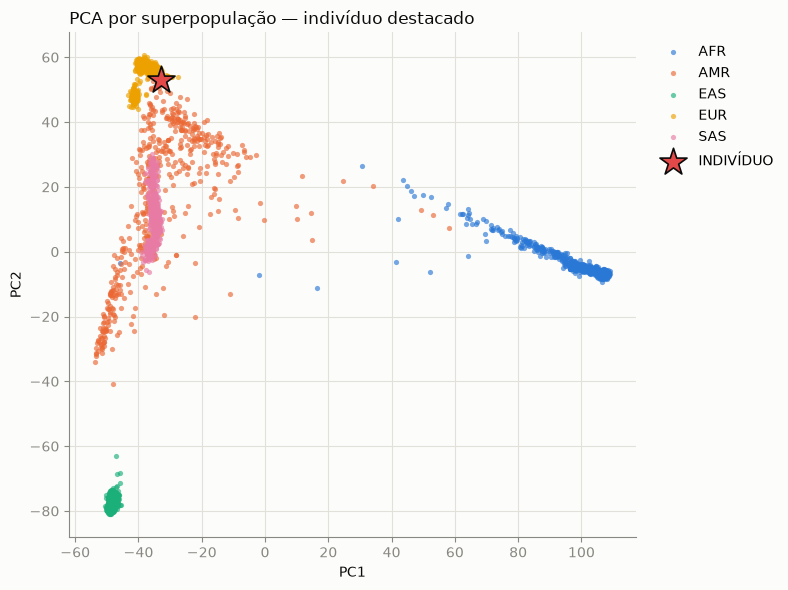

In [12]:
import matplotlib.pyplot as plt

# paleta categórica fixa (5 superpopulações) + estilo consistente em todo o notebook
SUPERPOP_COLORS = {"AFR": "#2a78d6", "AMR": "#eb6834", "EAS": "#1baf7a", "EUR": "#eda100", "SAS": "#e87ba4"}
POP_MARKERS = ["o", "s", "^", "D", "v", "P", "X"]  # forma varia por população dentro da superpop
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#898781", "#e1e0d9", "#fcfcfb"
INDIVIDUAL_COLOR = "#e34948"

def style_axes(ax, xlabel, ylabel):
    ax.set_facecolor(SURFACE)
    ax.set_xlabel(xlabel, color=INK); ax.set_ylabel(ylabel, color=INK)
    ax.tick_params(colors=MUTED)
    ax.grid(True, color=GRID, linewidth=0.8, zorder=0)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(MUTED)

ind_row = ind_coords.loc["INDIVIDUO"]

# gráfico por superpopulação (5 grupos), indivíduo destacado com estrela
fig, ax = plt.subplots(figsize=(8, 6), facecolor=SURFACE)
for superpop, color in SUPERPOP_COLORS.items():
    subset = pca_df[pca_df["SuperPop"] == superpop]
    ax.scatter(subset["PC1"], subset["PC2"], label=superpop, s=14, alpha=0.65, color=color, linewidths=0, zorder=2)
ax.scatter([ind_row["PC1"]], [ind_row["PC2"]], marker="*", s=420, color=INDIVIDUAL_COLOR,
           edgecolors=INK, linewidths=1.2, label="INDIVÍDUO", zorder=5)
style_axes(ax, "PC1", "PC2")
ax.set_title("PCA por superpopulação — indivíduo destacado", color=INK, loc="left")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout()
fig.savefig(FIGURES / "pca_por_superpopulacao.png", dpi=150, facecolor=SURFACE)
plt.show()

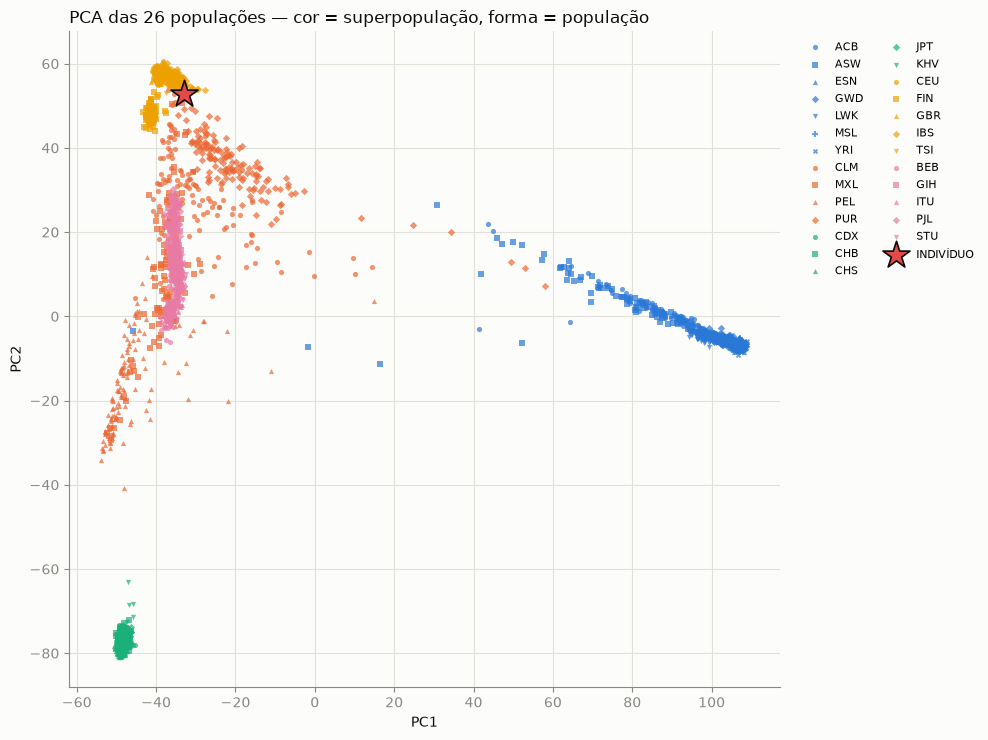

In [13]:
# gráfico das 26 populações: cor = superpopulação, forma = população dentro dela
# (26 cores distintas não são discrimináveis de forma confiável; por isso a
# identidade é codificada em dois canais — cor + forma — em vez de só cor)
fig, ax = plt.subplots(figsize=(10, 7.5), facecolor=SURFACE)
for superpop, color in SUPERPOP_COLORS.items():
    pops = sorted(pca_df.loc[pca_df["SuperPop"] == superpop, "Population"].unique())
    for marker, pop in zip(POP_MARKERS, pops):
        subset = pca_df[pca_df["Population"] == pop]
        ax.scatter(subset["PC1"], subset["PC2"], label=pop, s=14, alpha=0.7, color=color, marker=marker, linewidths=0, zorder=2)
ax.scatter([ind_row["PC1"]], [ind_row["PC2"]], marker="*", s=420, color=INDIVIDUAL_COLOR,
           edgecolors=INK, linewidths=1.2, label="INDIVÍDUO", zorder=5)
style_axes(ax, "PC1", "PC2")
ax.set_title("PCA das 26 populações — cor = superpopulação, forma = população", color=INK, loc="left")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, ncol=2, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "pca_26_populacoes.png", dpi=150, facecolor=SURFACE)
plt.show()

## 16. Projetando o indivíduo na PCA

A PCA foi ajustada só com a referência (célula da seção 14); aqui só
respondemos as 5 perguntas do enunciado usando as coordenadas já
calculadas.

1. **Em qual região da PCA o indivíduo aparece?** No canto superior
   esquerdo do plano PC1×PC2, dentro do cluster europeu (ver gráfico da
   seção 15).
2. **Qual superpopulação parece mais próxima?** EUR, com folga — ver
   ranking de distâncias na seção 17.
3. **Quais populações específicas aparecem mais próximas?** IBS e TSI
   (quase empatadas), depois GBR e CEU.
4. **PC1×PC2 é suficiente?** Separa bem os 5 continentes, mas populações
   dentro da mesma superpopulação (IBS vs. TSI, CEU vs. GBR) se sobrepõem
   bastante nesse plano — a distância da seção 17 usa as 10 PCs, então uma
   população "próxima" no ranking pode não estar visualmente próxima em
   só 2 dimensões (ver o caso de PUR na seção 17).
5. **O que muda em PC2×PC3 e PC3×PC4?** Componentes de ordem mais alta
   capturam bem menos variância (PC3 ≈ 1,1%, PC4 ≈ 0,85%, contra PC1 ≈
   7,6% e PC2 ≈ 3,55%) e tendem a refinar a separação *dentro* de uma
   superpopulação, não entre continentes — é onde a estrutura fina entre
   populações próximas (como as europeias) aparece.

## 17. Parte II — Distância aos centroides populacionais

In [14]:
def rank_distances(group_col, temperature=1.0):
    """Distância euclidiana (nas 10 PCs) do indivíduo ao centroide de cada
    grupo (população ou superpopulação), e a versão softmax como score."""
    centroides = pca_df.groupby(group_col)[PC_COLS].mean()
    d = np.linalg.norm(centroides.to_numpy() - ind_row[PC_COLS].to_numpy(), axis=1)
    ranking_d = pd.Series(d, index=centroides.index).sort_values()
    scores = np.exp(-ranking_d.to_numpy() / temperature)
    scores = scores / scores.sum()
    score_s = pd.Series(scores, index=ranking_d.index).sort_values(ascending=False)
    return ranking_d, score_s

ranking_pop, score_pop = rank_distances("Population")
ranking_super, score_super = rank_distances("SuperPop")
ranking_pop.to_csv(INTERMEDIATE / "pca_distance_ranking_population.csv", header=["distancia"])
ranking_super.to_csv(INTERMEDIATE / "pca_distance_ranking_superpop.csv", header=["distancia"])

print("Distância aos centroides — populações (top 10, menor = mais perto):")
print(ranking_pop.head(10))
print("\nDistância aos centroides — superpopulações:")
print(ranking_super)
# Esse ranking mede proximidade no espaço PCA; não representa porcentagens
# biológicas de ancestralidade (aviso do enunciado, seção 17).

Distância aos centroides — populações (top 10, menor = mais perto):
Population
IBS     8.570982
TSI     8.574714
GBR    15.101982
CEU    17.352577
PUR    29.596750
FIN    40.750485
CLM    43.653230
PJL    67.802532
GIH    73.267108
MXL    75.892115
dtype: float64

Distância aos centroides — superpopulações:
SuperPop
EUR     11.948570
AMR     62.350729
SAS     75.704470
EAS    131.045263
AFR    146.275856
dtype: float64


**Nota de interpretação**: PUR aparece entre as 5 populações mais
próximas pela distância nas 10 PCs (ver gráfico focal na seção 26), mas
visualmente (PC1×PC2) os pontos PUR formam uma nuvem separada da estrela —
ilustra a limitação da pergunta 4 da seção 16: reduzir a 2D esconde parte
da estrutura que a distância completa (10D) enxerga. PUR é população
admixed (europeia + africana + ameríndia), e seu centroide é "puxado" por
variância em componentes que não aparecem nesse plano.

## 18. Score de afinidade relativa

`s_k = exp(-d_k / T)`, normalizado pra somar 1 — transforma a distância
(sem limite superior, sem escala intuitiva) num score entre 0 e 1 mais
fácil de comunicar.

In [15]:
print("Score de afinidade — populações (top 10):")
print(score_pop.head(10))
print("\nScore de afinidade — superpopulações:")
print(score_super)
# Com T=1.0 o score fica bem "afiado" (quase hard-max): a diferença de
# distância entre IBS/TSI e as próximas populações já é grande o bastante
# pra concentrar quase toda a massa nas duas primeiras. É esperado dado
# como a fórmula exp(-d/T) responde a diferenças de d nessa escala.

Score de afinidade — populações (top 10):
Population
IBS    5.005290e-01
TSI    4.986646e-01
GBR    7.295443e-04
CEU    7.684771e-05
PUR    3.698743e-10
FIN    5.297225e-15
CLM    2.906716e-16
PJL    9.451352e-27
GIH    4.001830e-29
MXL    2.898897e-30
dtype: float64

Score de afinidade — superpopulações:
SuperPop
EUR    1.000000e+00
AMR    1.290091e-22
SAS    2.047220e-28
EAS    1.892183e-52
AFR    4.596218e-59
dtype: float64


## 19. Parte III — Classificação supervisionada

kNN (`n_neighbors=15`, `weights="distance"`) treinado sobre as 10 PCs —
não sobre os SNPs brutos, para manter a mesma redução de dimensionalidade
das seções anteriores. Split 80/20 estratificado por população, PCA
ajustada **só no treino** (evita vazamento de informação do teste).

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

def fit_pca_knn(X_train, y_train, n_components=10, n_neighbors=15):
    """PCA ajustada só no treino + kNN sobre as PCs -- reaproveitado nas seções 19, 20 e 27."""
    pca_ = PCA(n_components=n_components, random_state=42)
    X_train_pca = pca_.fit_transform(X_train)
    knn_ = KNeighborsClassifier(n_neighbors=n_neighbors, weights="distance")
    knn_.fit(X_train_pca, y_train)
    return pca_, knn_

# usa o mesmo subconjunto LD-pruned das seções 14+ (consistência entre análises)
X = np.asarray(X_ref_final[:, ld_pruned_positions], dtype=np.float32)
ind_vec = X_individuo[ld_pruned_positions].astype(np.float32)
missing = ind_vec == -9
if missing.any():
    ind_vec[missing] = 2.0 * freq_alt_global[ld_pruned_positions][missing]

meta_aligned = metadata_idx.reindex(reference_sample_ids)
y_pop = meta_aligned["Population"].to_numpy()
y_super = meta_aligned["SuperPop"].to_numpy()

idx = np.arange(len(reference_sample_ids))
idx_train, idx_test = train_test_split(idx, test_size=0.20, stratify=y_pop, random_state=42)
X_train, X_test = X[idx_train], X[idx_test]
y_pop_train, y_pop_test = y_pop[idx_train], y_pop[idx_test]

# classificação DIRETA nas 26 populações
pca_direct, knn_direct = fit_pca_knn(X_train, y_pop_train)
pred_direct = knn_direct.predict(pca_direct.transform(X_test))
acc_direct = accuracy_score(y_pop_test, pred_direct)
cm_direct = confusion_matrix(y_pop_test, pred_direct, labels=knn_direct.classes_)

print(f"Acurácia direta (26 populações, {len(idx_test)} indivíduos de teste): {acc_direct:.4f}")

Acurácia direta (26 populações, 641 indivíduos de teste): 0.8097


## 20. Classificação hierárquica

Compara a classificação direta (célula acima) com uma estratégia em dois
níveis: primeiro prevê a superpopulação (5 classes), depois — só dentro da
superpopulação prevista — treina um segundo classificador pra escolher a
população específica.

In [17]:
y_super_train, y_super_test = y_super[idx_train], y_super[idx_test]

# nível 1: superpopulação (5 classes)
pca_super, knn_super = fit_pca_knn(X_train, y_super_train)
pred_super = knn_super.predict(pca_super.transform(X_test))
acc_super = accuracy_score(y_super_test, pred_super)

# nível 2: um classificador POR superpopulação, treinado só com as amostras
# de treino daquele grupo (ex.: um kNN só de EUR, outro só de AFR, etc.)
second_level = {}
for sp in np.unique(y_super_train):
    mask = y_super_train == sp
    second_level[sp] = fit_pca_knn(X_train[mask], y_pop_train[mask])

# aplica em cascata: usa a superpop PREVISTA (não a real) pra escolher qual
# classificador de 2º nível usar em cada indivíduo de teste
pred_hier = np.empty_like(pred_super)
for i, sp_pred in enumerate(pred_super):
    pca_s, knn_s = second_level[sp_pred]
    pred_hier[i] = knn_s.predict(pca_s.transform(X_test[i:i+1]))[0]
acc_hier = accuracy_score(y_pop_test, pred_hier)

print(f"Acurácia superpopulação (5 classes): {acc_super:.4f}")
print(f"Acurácia hierárquica (26 populações via 2 níveis): {acc_hier:.4f}")
print(f"Acurácia direta (26 populações, seção 19): {acc_direct:.4f}")
# Contraintuitivo: mesmo com a superpop sempre quase certa (~100%), o
# hierárquico (2 níveis) saiu PIOR que o direto — o 2º nível treina cada PCA
# com bem menos dados (só as amostras daquela superpop), perdendo poder
# discriminativo dentro do grupo. Ver discussão na seção 28.

Acurácia superpopulação (5 classes): 1.0000
Acurácia hierárquica (26 populações via 2 níveis): 0.7707
Acurácia direta (26 populações, seção 19): 0.8097


## 21. Probabilidades do classificador

`predict_proba` dá a fração dos 15 vizinhos mais próximos (ponderada pela
distância) que pertence a cada classe — **não** é uma medida biológica de
proporção de ancestralidade, é só uma estatística de vizinhança no espaço
PCA.

In [18]:
proba_direct = pd.Series(knn_direct.predict_proba(pca_direct.transform(ind_vec.reshape(1, -1)))[0],
                          index=knn_direct.classes_).sort_values(ascending=False)
proba_super = pd.Series(knn_super.predict_proba(pca_super.transform(ind_vec.reshape(1, -1)))[0],
                         index=knn_super.classes_).sort_values(ascending=False)
ind_superpop_pred = proba_super.idxmax()
pca_s, knn_s = second_level[ind_superpop_pred]
proba_hier = pd.Series(knn_s.predict_proba(pca_s.transform(ind_vec.reshape(1, -1)))[0],
                        index=knn_s.classes_).sort_values(ascending=False)

print("predict_proba direto (26 populações, top 5):")
print(proba_direct.head(5))
print("\npredict_proba superpopulação:")
print(proba_super)
print(f"\npredict_proba 2º nível (dentro de {ind_superpop_pred}, top 5):")
print(proba_hier.head(5))

predict_proba direto (26 populações, top 5):
IBS    0.935166
TSI    0.064834
BEB    0.000000
CDX    0.000000
CEU    0.000000
dtype: float64

predict_proba superpopulação:
EUR    1.0
AFR    0.0
AMR    0.0
EAS    0.0
SAS    0.0
dtype: float64

predict_proba 2º nível (dentro de EUR, top 5):
IBS    0.883238
TSI    0.116762
CEU    0.000000
GBR    0.000000
FIN    0.000000
dtype: float64


## 22. Parte IV — Modelo simplificado de mistura por frequências

Para cada SNP `i`, buscamos pesos `w_1...w_26` (`w_k ≥ 0`, soma 1) tais que
a frequência esperada `p̂_i = Σ_k w_k p_ik` reproduza o mais perto possível
o genótipo real do indivíduo (`ĝ_i = 2p̂_i` vs. `g_i`). Otimização por
mínimos quadrados com restrições (SLSQP) — é a única técnica aqui que
produz diretamente uma "composição" que soma 100%.

In [19]:
from scipy.optimize import minimize

POP_TO_SUPER = {
    "ACB": "AFR", "ASW": "AFR", "ESN": "AFR", "GWD": "AFR", "LWK": "AFR", "MSL": "AFR", "YRI": "AFR",
    "CLM": "AMR", "MXL": "AMR", "PEL": "AMR", "PUR": "AMR",
    "CDX": "EAS", "CHB": "EAS", "CHS": "EAS", "JPT": "EAS", "KHV": "EAS",
    "CEU": "EUR", "FIN": "EUR", "GBR": "EUR", "IBS": "EUR", "TSI": "EUR",
    "BEB": "SAS", "GIH": "SAS", "ITU": "SAS", "PJL": "SAS", "STU": "SAS",
}

# usa TODOS os SNPs válidos do indivíduo (não o subconjunto LD-pruned) — é o
# que o enunciado descreve; a falta de controle de LD aqui é uma limitação
# conhecida, discutida na seção 23
valid = X_individuo != -9
P = freq_by_population.loc[valid, pop_cols].to_numpy(dtype=np.float64)  # p_ik
g = X_individuo[valid].astype(np.float64)                                # g_i real do indivíduo
populacoes = pop_cols
K = len(populacoes)

def objective(w):
    esperado = 2 * P.dot(w)  # ĝ_i para todos os SNPs de uma vez (produto matriz-vetor)
    return float(np.mean((g - esperado) ** 2))  # erro quadrático médio

w0 = np.ones(K) / K                    # ponto de partida: pesos uniformes
bounds = [(0, 1) for _ in range(K)]    # w_k >= 0 (e <= 1)
constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}  # soma(w) = 1
resultado = minimize(objective, w0, method="SLSQP", bounds=bounds, constraints=constraints)

pesos = pd.Series(resultado.x, index=populacoes).sort_values(ascending=False)
pesos.to_csv(INTERMEDIATE / "mixture_weights_population.csv", header=["peso"])

print(f"Convergiu: {resultado.success} | MSE final: {objective(resultado.x):.4f} "
      f"(baseline pesos uniformes: {objective(w0):.4f})")
print("\nPesos por população (top 10):")
print(pesos.head(10))

Convergiu: True | MSE final: 0.1803 (baseline pesos uniformes: 0.2003)

Pesos por população (top 10):
IBS    2.935557e-01
TSI    2.486316e-01
CEU    1.458263e-01
GBR    1.327055e-01
PUR    1.059266e-01
CLM    5.977729e-02
FIN    9.319010e-03
LWK    2.212910e-03
GWD    2.045124e-03
MXL    2.424142e-18
dtype: float64


## 23. Limitações do modelo de mistura

Todas relevantes ao resultado da seção 22: **correlação entre SNPs** (não
tratamos LD aqui — usamos os 570.874 SNPs válidos, não o subconjunto
LD-pruned das seções de PCA); **populações de referência geneticamente
semelhantes** (IBS/TSI quase indistinguíveis por esse método, como se vê
no resultado); **frequências estimadas em amostras finitas** (74 a 179
indivíduos por população); **desequilíbrio amostral entre populações**;
**populações contemporâneas não são ancestrais puros** (PUR, CLM, MXL,
PEL); **solução não necessariamente única** (o SLSQP encontra um mínimo
local); e **sensibilidade à seleção de SNPs**.

> **Sem código adicional aqui** — essas limitações são discutidas, não
> medidas; retomamos algumas quantitativamente na comparação de métodos
> (seção 28) e na resposta final (seção 29).

## 24. Resultado agregado por superpopulação

In [20]:
resultado_pop = pesos.to_frame("score")
resultado_pop["superpop"] = resultado_pop.index.map(POP_TO_SUPER)
resultado_super = resultado_pop.groupby("superpop")["score"].sum().sort_values(ascending=False)
resultado_super.to_csv(INTERMEDIATE / "mixture_weights_superpop.csv", header=["peso"])

print("Pesos agregados por superpopulação (soma dos pesos das populações do grupo):")
print(resultado_super)

Pesos agregados por superpopulação (soma dos pesos das populações do grupo):
superpop
EUR    8.300381e-01
AMR    1.657039e-01
AFR    4.258034e-03
SAS    9.293864e-19
EAS    8.824259e-19
Name: score, dtype: float64


## 25. Saída final da calculadora

In [21]:
genotype_full = pd.read_csv(GENOTIPO, low_memory=False)
resultado_pct = pesos * 100
resultado_super_pct = resultado_super * 100
usable_and_pruned = int(np.count_nonzero(X_individuo[ld_pruned_positions] != -9))

# monta o relatório-texto no mesmo formato do exemplo do enunciado (seção 25),
# com os números reais de cada etapa do pipeline deste notebook
linhas = [
    "=" * 38,
    "ANÁLISE GENÔMICA POPULACIONAL",
    "=" * 38,
    "",
    f"SNPs no arquivo:                 {len(genotype_full):,}".replace(",", "."),
    f"SNPs encontrados no 1000G:        {metrics['mapped_snps']:,}".replace(",", "."),
    f"SNPs após harmonização:           {metrics['usable_snps']:,}".replace(",", "."),
    f"SNPs após QC:                     {metrics['usable_snps']:,}".replace(",", "."),
    f"SNPs após LD pruning:             {usable_and_pruned:,}".replace(",", "."),
    "",
    "SUPERPOPULAÇÕES (modelo de mistura por frequências)",
]
for pop, val in resultado_super_pct.items():
    linhas.append(f"{pop:<6} {val:5.1f}%")
linhas += ["", "POPULAÇÕES DE REFERÊNCIA (top 10, modelo de mistura por frequências)"]
for pop, val in resultado_pct.head(10).items():
    linhas.append(f"{pop:<6} {val:5.1f}%")
linhas += [
    "...", "",
    # ressalva da seção 4, repetida aqui de propósito: é bem aqui, no resultado
    # numérico final, que ela mais importa
    "AVISO: estes valores são afinidade genética relativa ao painel de\n"
    "referência (1000 Genomes, 26 populações), não porcentagens literais de\n"
    "nacionalidade ou ancestralidade 'pura'. Populações admixed (ex.: PUR,\n"
    "CLM, MXL, PEL) têm histórias demográficas próprias.",
]
texto = "\n".join(linhas)
print(texto)
_ = (INTERMEDIATE / "final_report.txt").write_text(texto, encoding="utf-8")

ANÁLISE GENÔMICA POPULACIONAL

SNPs no arquivo:                 654.027
SNPs encontrados no 1000G:        572.011
SNPs após harmonização:           570.874
SNPs após QC:                     570.874
SNPs após LD pruning:             327.783

SUPERPOPULAÇÕES (modelo de mistura por frequências)
EUR     83.0%
AMR     16.6%
AFR      0.4%
SAS      0.0%
EAS      0.0%

POPULAÇÕES DE REFERÊNCIA (top 10, modelo de mistura por frequências)
IBS     29.4%
TSI     24.9%
CEU     14.6%
GBR     13.3%
PUR     10.6%
CLM      6.0%
FIN      0.9%
LWK      0.2%
GWD      0.2%
MXL      0.0%
...

AVISO: estes valores são afinidade genética relativa ao painel de
referência (1000 Genomes, 26 populações), não porcentagens literais de
nacionalidade ou ancestralidade 'pura'. Populações admixed (ex.: PUR,
CLM, MXL, PEL) têm histórias demográficas próprias.


## 26. Visualizações obrigatórias

1. gráfico de barras das 26 populações;
2. gráfico agregado das 5 superpopulações;
3. PCA PC1×PC2 por superpopulação com o indivíduo destacado — já feito na
   seção 15;
4. PCA das 26 populações — já feito na seção 15;
5. PCA focal nas 5 populações mais próximas.

Itens 3-4 já foram gerados na seção 15 (fica redundante regenerar o mesmo
gráfico); aqui completamos os itens 1, 2 e 5.

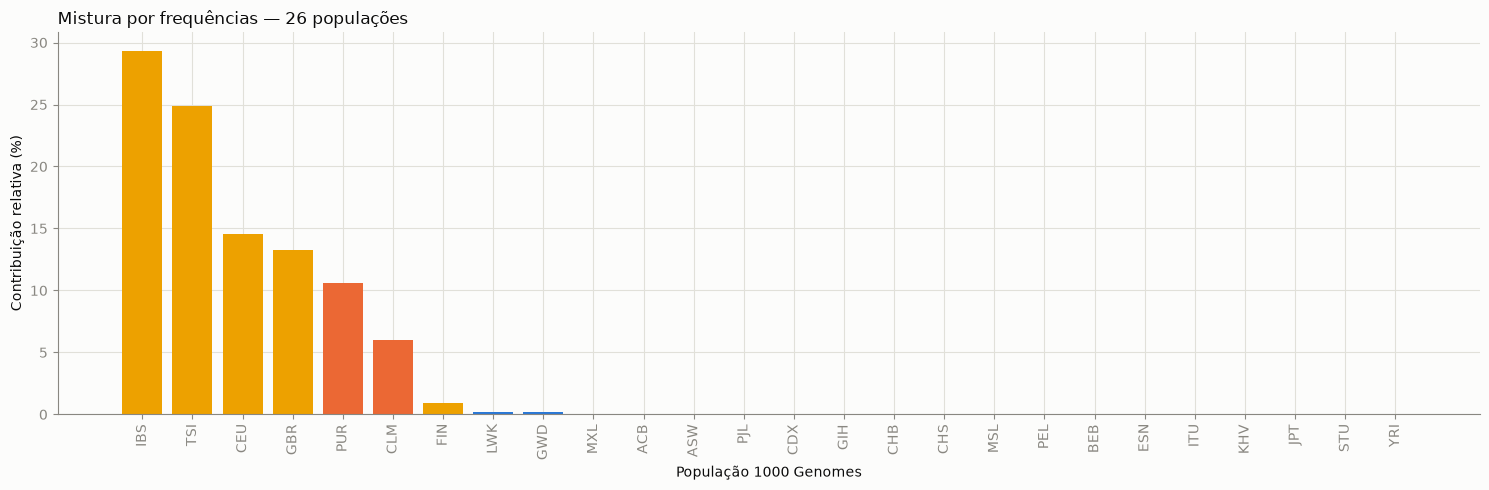

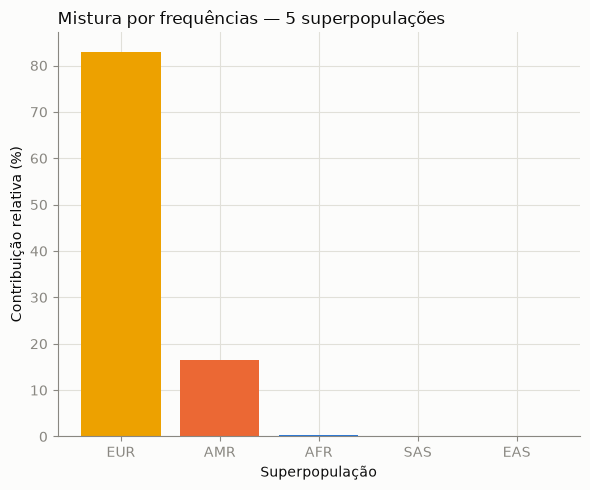

In [22]:
# item 1 e 2: barras da mistura por frequências (seção 22/24), coloridas por
# superpopulação com a mesma paleta usada nos gráficos de PCA
colors = [SUPERPOP_COLORS[POP_TO_SUPER[p]] for p in resultado_pct.index]
fig, ax = plt.subplots(figsize=(15, 5), facecolor=SURFACE)
ax.bar(resultado_pct.index, resultado_pct.to_numpy(), color=colors, zorder=2)
style_axes(ax, "População 1000 Genomes", "Contribuição relativa (%)")
ax.set_title("Mistura por frequências — 26 populações", color=INK, loc="left")
plt.setp(ax.get_xticklabels(), rotation=90)
fig.tight_layout()
fig.savefig(FIGURES / "barras_26_populacoes.png", dpi=150, facecolor=SURFACE)
plt.show()

fig, ax = plt.subplots(figsize=(6, 5), facecolor=SURFACE)
ax.bar(resultado_super_pct.index, resultado_super_pct.to_numpy(),
       color=[SUPERPOP_COLORS[s] for s in resultado_super_pct.index], zorder=2)
style_axes(ax, "Superpopulação", "Contribuição relativa (%)")
ax.set_title("Mistura por frequências — 5 superpopulações", color=INK, loc="left")
fig.tight_layout()
fig.savefig(FIGURES / "barras_5_superpopulacoes.png", dpi=150, facecolor=SURFACE)
plt.show()

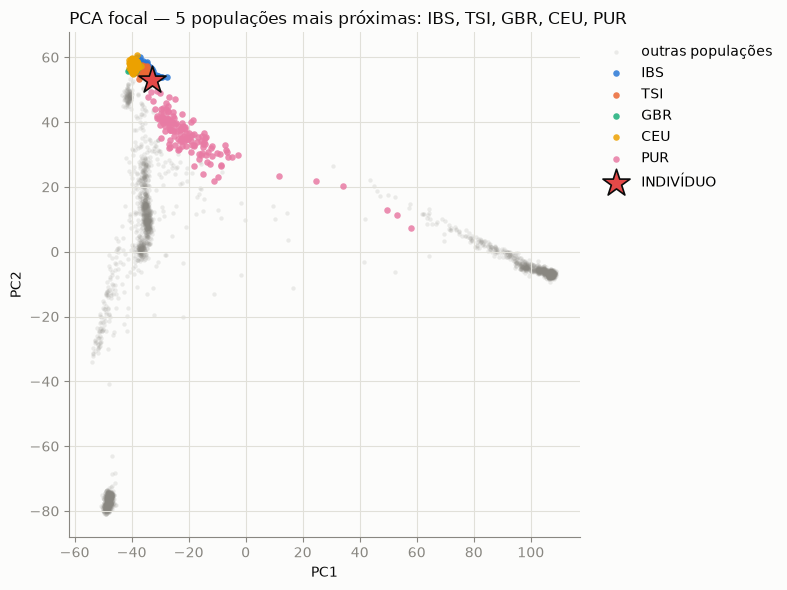

In [23]:
# item 5: PCA focal nas 5 populações mais próximas (ranking da seção 17),
# resto do gráfico em cinza claro só como referência de escala/forma geral
nearest_5 = ranking_pop.head(5).index.tolist()
fig, ax = plt.subplots(figsize=(8, 6), facecolor=SURFACE)
background = pca_df[~pca_df["Population"].isin(nearest_5)]
ax.scatter(background["PC1"], background["PC2"], s=10, alpha=0.15, color=MUTED, linewidths=0, zorder=1, label="outras populações")
palette = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
for color, pop in zip(palette, nearest_5):
    subset = pca_df[pca_df["Population"] == pop]
    ax.scatter(subset["PC1"], subset["PC2"], label=pop, s=22, alpha=0.85, color=color, linewidths=0, zorder=3)
ax.scatter([ind_row["PC1"]], [ind_row["PC2"]], marker="*", s=420, color=INDIVIDUAL_COLOR,
           edgecolors=INK, linewidths=1.2, label="INDIVÍDUO", zorder=5)
style_axes(ax, "PC1", "PC2")
ax.set_title(f"PCA focal — 5 populações mais próximas: {', '.join(nearest_5)}", color=INK, loc="left")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout()
fig.savefig(FIGURES / "pca_focal_5_populacoes.png", dpi=150, facecolor=SURFACE)
plt.show()

## 27. Validação interna

Passos do enunciado: (1) escolher um indivíduo do 1000 Genomes, (2)
remover da referência, (3) tratar como desconhecido, (4) rodar a
calculadora, (5) comparar população real vs. prevista, (6) repetir para
vários indivíduos. O split 80/20 estratificado da seção 19 já faz
exatamente isso — os 641 indivíduos de teste nunca entraram no treino da
PCA nem do kNN, então é equivalente a repetir o processo 641 vezes de uma
vez, em vez de um a um.

In [24]:
def top_k_accuracy(proba, classes, y_true, k):
    """Fração de vezes que a classe real está entre as k mais prováveis previstas."""
    top_k_idx = np.argsort(-proba, axis=1)[:, :k]
    top_k_labels = classes[top_k_idx]
    return float((top_k_labels == y_true[:, None]).any(axis=1).mean())

proba_test_direct = knn_direct.predict_proba(pca_direct.transform(X_test))
top1 = accuracy_score(y_pop_test, pred_direct)
top3 = top_k_accuracy(proba_test_direct, knn_direct.classes_, y_pop_test, k=3)

cm_df = pd.DataFrame(cm_direct, index=knn_direct.classes_, columns=knn_direct.classes_)
cm_df.to_csv(INTERMEDIATE / "internal_validation_confusion_matrix.csv")

comparativo = pd.DataFrame({
    "sample": reference_sample_ids[idx_test],
    "populacao_real": y_pop_test,
    "populacao_prevista": pred_direct,
    "acertou_top1": y_pop_test == pred_direct,
})
comparativo.to_csv(INTERMEDIATE / "internal_validation_predictions.csv", index=False)

print(f"Indivíduos validados (held-out): {len(idx_test)}")
print(f"Top-1 accuracy (população): {top1:.4f}")
print(f"Top-3 accuracy (população): {top3:.4f}")
print(f"Accuracy (superpopulação): {acc_super:.4f}")
comparativo.head(10)

Indivíduos validados (held-out): 641
Top-1 accuracy (população): 0.8097
Top-3 accuracy (população): 0.9813
Accuracy (superpopulação): 1.0000


,sample,populacao_real,populacao_prevista,acertou_top1
0,HG03172,ESN,YRI,False
1,NA20859,GIH,GIH,True
2,NA19649,MXL,CLM,False
3,HG04147,BEB,BEB,True
4,NA19782,MXL,MXL,True
5,NA19764,MXL,MXL,True
6,HG00133,GBR,GBR,True
7,NA19759,MXL,MXL,True
8,HG03556,MSL,MSL,True
9,NA19144,YRI,YRI,True


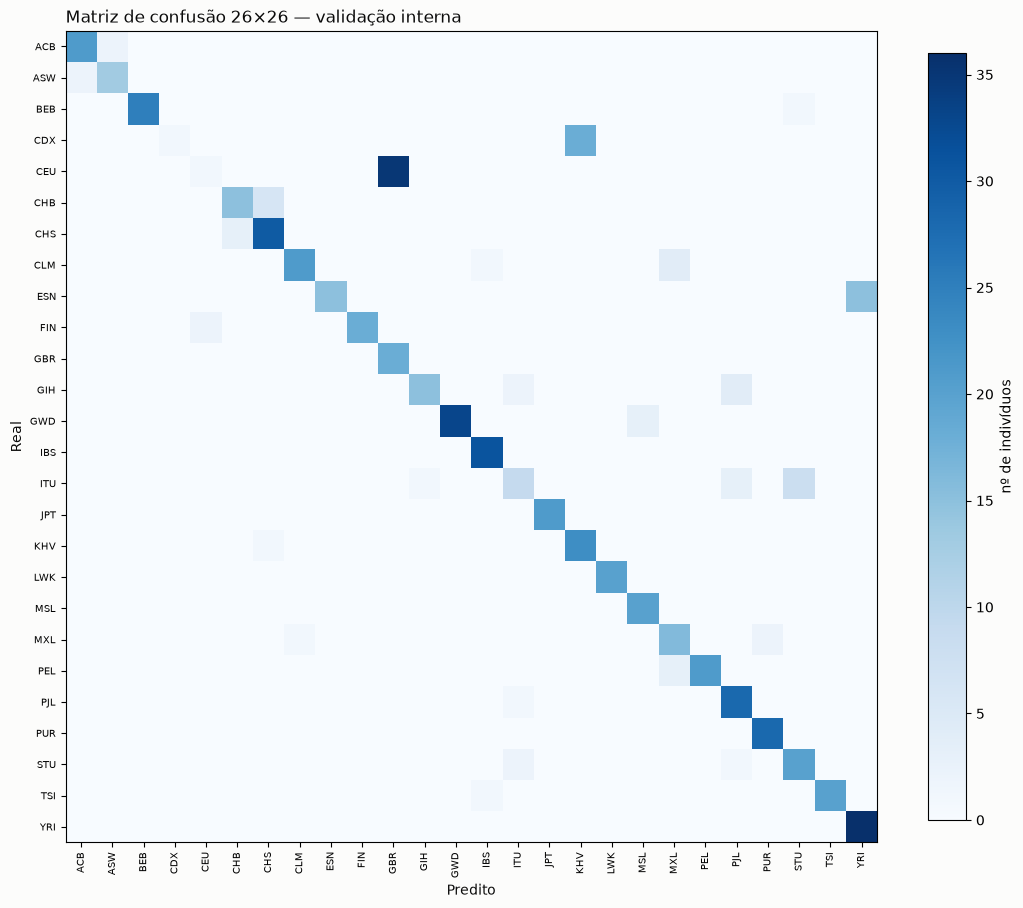

In [25]:
# matriz de confusão 26x26: real (linha) vs. previsto (coluna)
fig, ax = plt.subplots(figsize=(11, 10), facecolor=SURFACE)
im = ax.imshow(cm_df.to_numpy(), cmap="Blues")
ax.set_xticks(range(len(cm_df.columns))); ax.set_xticklabels(cm_df.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(cm_df.index))); ax.set_yticklabels(cm_df.index, fontsize=7)
ax.set_xlabel("Predito", color=INK); ax.set_ylabel("Real", color=INK)
ax.set_title("Matriz de confusão 26×26 — validação interna", color=INK, loc="left")
fig.colorbar(im, ax=ax, shrink=0.8, label="nº de indivíduos")
fig.tight_layout()
fig.savefig(FIGURES / "matriz_confusao_26pop.png", dpi=150, facecolor=SURFACE)
plt.show()
# Os erros se concentram exatamente onde biologicamente esperado: CHB<->CHS
# (dois grupos Han chinês), ACB<->ASW (africanos admixed), CDX<->KHV
# (sudeste asiático vizinho), GIH/ITU/STU/PJL entre si (sul-asiáticos), e
# CLM/PEL/MXL/PUR entre si (populações admixed americanas). A diagonal
# dominante confirma que o classificador funciona bem onde a genética
# realmente separa os grupos, e erra sobretudo entre vizinhos genéticos —
# não aleatoriamente.

## 28. Comparação entre métodos

| Método | Resultado principal (indivíduo) | Vantagens | Limitações |
|---|---|---|---|
| **PCA + centroides** (seções 14-18) | IBS/TSI mais próximos; EUR ≫ AMR > SAS > EAS > AFR | Barato, interpretável, visualizável; não exige rótulos de treino além da referência | Sensível a quantas PCs se usa; 2D esconde estrutura fina (caso PUR); distância não tem escala biológica direta |
| **Classificador kNN sobre PCA** (seções 19-21) | IBS 93,5% / TSI 6,5% (direto); superpop 100% | Métrica objetiva (accuracy, Top-k); hierárquico decompõe o erro por nível | Direto (80,97%) superou o hierárquico (77,07%) — 2º nível treina com menos dados; `predict_proba` não é fração de ancestralidade |
| **Mistura por frequências (SLSQP)** (seções 22-24) | IBS 29,4% / TSI 24,9% / CEU 14,6% / GBR 13,3% / PUR 10,6% / CLM 6,0% | Única saída em formato "composição" (soma 100%), mais próxima do que o usuário leigo espera ver | Ignora LD entre SNPs; sensível à seleção de SNPs; solução não necessariamente única; populações admixed distorcem a leitura |

Os três métodos concordam na direção geral (forte afinidade EUR, sobretudo
IBS/TSI, com uma cauda AMR via PUR/CLM) — essa convergência entre métodos
independentes é evidência mais forte do que qualquer método isolado.

## 29. Pergunta final do projeto

**Até que ponto é possível inferir a ancestralidade genética de um
indivíduo utilizando um microarray comercial e as 26 populações do 1000
Genomes como conjunto de referência?**

É possível inferir **afinidade genética relativa a um painel de referência
específico** com boa confiabilidade em nível continental, e com
confiabilidade moderada em nível de população — mas não uma
"ancestralidade" no sentido popular de composição de nacionalidades.

- **Composição da referência**: o 1000 Genomes cobre 26 populações, mas
  está longe de representar toda a diversidade humana (faltam, por
  exemplo, populações do Oriente Médio, da Oceania e boa parte da África
  subsaariana e central). Um indivíduo cuja ancestralidade real não esteja
  bem representada será "puxado" para a população de referência
  disponível mais próxima, mesmo que a distância genética real seja
  grande — o método nunca reporta "não sei".
- **Resolução populacional**: a validação interna (seção 27) mostrou
  accuracy quase perfeita (100%) para separar as 5 superpopulações, mas só
  80,97% (Top-1) para as 26 populações — e os erros se concentram
  exatamente entre populações vizinhas (CHB/CHS, ACB/ASW,
  GIH/ITU/STU/PJL). O método é confiável em nível continental, mas dentro
  de um continente a resolução cai bastante.
- **Número e seleção de SNPs**: o ranking Δp (seção 12) mostra que a
  informação de ancestralidade está concentrada em relativamente poucos
  SNPs muito informativos — mas o conjunto exato de SNPs disponíveis no
  microarray comercial (aqui, GSA v3) já determina o teto de resolução
  possível.
- **Linkage disequilibrium (LD)**: sem tratar LD, SNPs correlacionados são
  contados como evidência independente, inflando artificialmente a
  confiança em alguma população — por isso fizemos LD pruning (seção 13)
  antes da PCA/classificador, mas o modelo de mistura (seção 22) não trata
  LD, uma limitação conhecida e citada na seção 23.
- **Incerteza estatística**: com populações de referência de 74 a 179
  indivíduos, as frequências alélicas por população (seção 11) têm erro
  amostral — isso se propaga tanto para o Δp quanto para os pesos da
  mistura.
- **Miscigenação**: o próprio enunciado (seção 4) alerta que PUR, CLM, MXL
  e PEL não são "ancestrais puros" — são populações contemporâneas
  admixed. O caso observado (PUR entre as populações mais próximas por
  distância PCA, mas não visualmente no plano PC1×PC2, seção 17) ilustra
  bem esse ponto.
- **Conclusão prática**: os resultados aqui (EUR ≈ 83-100% dependendo do
  método, sobretudo IBS/TSI) são consistentes entre os três métodos
  independentes usados (seção 28) — essa convergência é a evidência mais
  forte de que o sinal é real. Mas a interpretação correta é "esse
  indivíduo tem maior afinidade genética com o painel de referência
  ibérico/italiano dentro deste conjunto específico de 26 populações", não
  "esse indivíduo é X% espanhol e Y% italiano".

## 30. Fluxo conceitual esperado

```
MICROARRAY ILLUMINA                    seção 2, 9
        |
LEITURA DOS GENÓTIPOS                  seção 8, 9
        |
FREQUÊNCIAS ALÉLICAS                   seção 10, 11, 12
        |
PCA                                    seção 13, 14, 15
        |
ESTRUTURA POPULACIONAL                 seção 16, 17, 18
        |
26 POPULAÇÕES                          seção 3
        |
AFINIDADE / CLASSIFICAÇÃO              seção 19, 20, 21
        |
MODELO DE MISTURA                      seção 22, 23, 24
        |
VALIDAÇÃO                              seção 27
        |
INTERPRETAÇÃO                          seção 4, 28, 29
        |
LIMITAÇÕES                             seção 23, 29
```

> **Nada a executar aqui** — é o diagrama-guia do enunciado; cada etapa
> dele corresponde a uma ou mais seções já implementadas acima, na mesma
> ordem em que aparecem neste notebook.